# 02 · Feature Engineering — Quick Test & Validation
**Script chính:** `scripts/run_features.py`  
**Notebook này:** Load dataset_featured → kiểm tra 8 nhóm features, NaN, phân phối, correlation.

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.config import load_config, get_feature_cols, prepare_feature_sets, REMOVED_FEATURES
from src.utils.io import load

cfg = load_config(ROOT / 'configs' / 'base.yaml')

## 1. Load & Basic Checks

In [2]:
df = load(cfg.dir_processed / 'dataset_featured.parquet')

feature_cols = get_feature_cols(list(df.columns))
feature_sets = prepare_feature_sets(df, feature_cols)
full_cols = feature_sets['full_cols']
base_cols = feature_sets['base_cols']
macro_cols = feature_sets['macro_cols']

print(f"Shape: {df.shape}")
print(f"Tickers: {df.index.get_level_values('ticker').nunique()}")
print(f"Dates: {df.index.get_level_values('date').nunique()}")
print(f"\nFeature counts:")
print(f"  Full selector: {len(full_cols)}")
print(f"  Base: {len(base_cols)}")
print(f"  Macro-interaction: {len(macro_cols)}")

# Verify no target leakage in feature cols
forbidden = {'tb_label', 'tb_barrier', 'tb_return', 'daily_vol', 't1',
             'holding_td', 'alpha_ret', 'alpha_label', 'alpha_ext_label'}
leaked = set(full_cols) & forbidden
assert not leaked, f"Target leakage: {leaked}"
print("\nOK: No target leakage in feature columns")

Shape: (173604, 80)
Tickers: 68
Dates: 2553

Feature counts:
  Full selector: 58
  Base: 48
  Macro-interaction: 10

OK: No target leakage in feature columns


## 1b. Data Inspection — nhìn thẳng vào features

LƯU Ý: rolling features (`mom_63d`, `sma200`, `vol_63d`...) cần 63-200 ngày warmup, nên `head()` đầu dataset (2016-01) sẽ NaN nhiều. Cell này show 2 view:
- (a) head(5) — vùng warmup, NaN nhiều = bình thường
- (b) sample sau warmup (2021-06-15) — dữ liệu thực sự đi vào model

In [3]:
print("--- (a) WARMUP rows: head(5) — rolling features NaN, bình thường ---")
print(df[full_cols].head(5).round(4).to_string())

print("\n--- (b) POST-WARMUP sample: 1 ngày sau warmup (2021-06-15), 10 ticker ---")
sample_date = pd.Timestamp('2021-06-15')
post_sample = df.loc[df.index.get_level_values('date') == sample_date, full_cols]
if len(post_sample) == 0:
    populated_dates = df.dropna(subset=['mom_63d']).index.get_level_values('date').unique()
    sample_date = populated_dates[len(populated_dates) // 2]
    post_sample = df.loc[df.index.get_level_values('date') == sample_date, full_cols]
print(f"Date: {sample_date.date()} — {len(post_sample)} tickers")
print(post_sample.head(10).round(4).to_string())

print("\n--- (c) df[full_cols].describe().T (chỉ tính trên non-NaN, full dataset) ---")
print(df[full_cols].describe().T.round(4).to_string())

print("\n--- (d) Sample chi tiết: AAPL trên 1 ngày POST-warmup, ALL 58 features ---")
aapl_row = df.loc[(sample_date, 'AAPL'), full_cols]
print(aapl_row.round(4).to_string())

print(f"\n--- (e) Memory: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB ---")
print(f"--- Dtype counts: ---")
print(df[full_cols].dtypes.value_counts().to_string())

--- (a) WARMUP rows: head(5) — rolling features NaN, bình thường ---
                   ret_1d  ret_5d  ret_10d  ret_21d  mom_63d  rsi_14d  position_in_range_20d  ret_1d_lag1  ret_1d_lag2  ret_1d_lag3  macd_signal  macd_hist  bb_pctb_20d  stoch_k_14d  adx_14d  price_sma20  price_sma50  sma_cross_5_20  price_sma200  mom_accel_5d  trend_strength_21d  mean_rev_5d  vol_ma_ratio_20d  dollar_volume_21d  abnormal_volume  vol_5d  vol_10d  vol_21d  vol_63d  atr_norm_14d  gk_vol_20d  vol_skew_21d  skew_21d  amihud_illiq_21d  turnover_21d  downside_vol_21d  max_dd_21d  rolling_beta_63d  resid_ret_21d  idio_vol_21d  rel_strength_21d  rel_strength_63d  cs_ret_zscore_1d  cs_vol_zscore_21d  cs_mom_zscore_63d  overnight_gap  close_position  mom_quality  zspread  zspread_ma5  zspread_change_5d  p_high_x_mom_63d  p_high_x_vol_21d  stress_reversal  beta_regime  spread_momentum  dispersion_adjusted_vol  cs_mom_x_yield
date       ticker                                                                       

## 2. REMOVED_FEATURES — verify pruned

In [4]:
still_present = set(full_cols) & REMOVED_FEATURES
assert not still_present, f"REMOVED_FEATURES still in selector: {still_present}"

actually_in_df = REMOVED_FEATURES & set(df.columns)
actually_pruned = REMOVED_FEATURES - set(df.columns)
print(f"REMOVED_FEATURES: {len(REMOVED_FEATURES)} defined")
print(f"  Present in df (generated but excluded from selector): {len(actually_in_df)}")
print(f"  Not in df at all (no longer generated): {len(actually_pruned)}")
print("OK: All REMOVED_FEATURES excluded from selector")

REMOVED_FEATURES: 13 defined
  Present in df (generated but excluded from selector): 0
  Not in df at all (no longer generated): 13
OK: All REMOVED_FEATURES excluded from selector


## 3. NaN Report by Feature Group

In [5]:
nan_pct = df[full_cols].isna().mean().sort_values(ascending=False) * 100
high_nan = nan_pct[nan_pct > 1.0]
print(f"Features with >1% NaN ({len(high_nan)}/{len(full_cols)}):")
if len(high_nan):
    print(high_nan.to_string())

overall = df[full_cols].isna().mean().mean()
print(f"\nOverall NaN rate: {overall:.2%}")
assert overall < 0.05, f"Overall NaN rate too high: {overall:.2%}"

# NaN by group
print(f"\nNaN by group:")
print(f"  Base:  {df[base_cols].isna().mean().mean():.2%}")
print(f"  Macro: {df[macro_cols].isna().mean().mean():.2%}")
print("OK: NaN rates acceptable")

Features with >1% NaN (17/58):
price_sma200         3.879519
cs_mom_x_yield       2.470565
cs_mom_zscore_63d    2.470565
mom_quality          2.470565
rel_strength_63d     2.470565
spread_momentum      2.470565
mom_63d              2.470565
stress_reversal      2.314463
idio_vol_21d         1.605954
price_sma50          1.529343
macd_hist            1.294325
macd_signal          1.294325
resid_ret_21d        1.256307
beta_regime          1.253427
rolling_beta_63d     1.253427
vol_63d              1.214258
adx_14d              1.018410

Overall NaN rate: 0.84%

NaN by group:
  Base:  0.80%
  Macro: 1.03%
OK: NaN rates acceptable


## 4. Feature Distributions — Spot Check

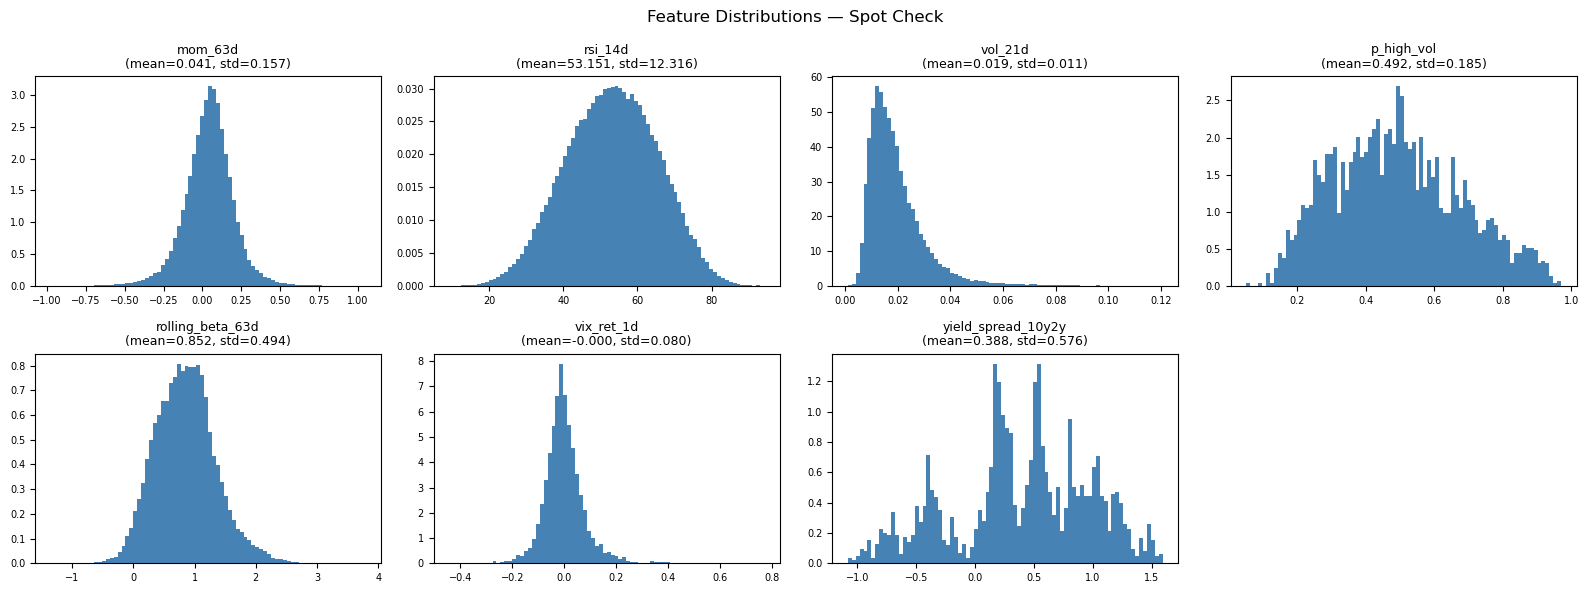

In [6]:
spot_features = ['mom_5d', 'mom_63d', 'rsi_14d', 'vol_21d', 'p_high_vol',
                  'rolling_beta_63d', 'vix_ret_1d', 'yield_spread_10y2y']
spot_features = [f for f in spot_features if f in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, feat in zip(axes.flat, spot_features):
    vals = df[feat].dropna()
    ax.hist(vals, bins=80, color='steelblue', edgecolor='none', density=True)
    ax.set_title(f'{feat}\n(mean={vals.mean():.3f}, std={vals.std():.3f})', fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(spot_features):]:
    ax.set_visible(False)
plt.suptitle('Feature Distributions — Spot Check', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Cross-Sectional Check — Same-date features phải giống nhau

In [7]:
# Macro features should be identical across tickers on same date
macro_check = ['vix_ret_1d', 'vxn_ret_1d', 'yield_spread_10y2y', 'p_high_vol']
macro_check = [c for c in macro_check if c in df.columns]

sample_dates = df.index.get_level_values('date').unique()[-10:]
for col in macro_check:
    sub = df.loc[df.index.get_level_values('date').isin(sample_dates), col]
    by_date = sub.groupby(level='date')
    spread = (by_date.max() - by_date.min()).abs()
    max_spread = spread.max()
    assert max_spread < 1e-10, f"{col} varies across tickers on same date! max_spread={max_spread}"

print(f"Checked {len(macro_check)} macro features: identical across tickers on same date")

# Ticker-specific features should vary across tickers
ticker_check = ['mom_5d', 'rsi_14d', 'vol_21d']
ticker_check = [c for c in ticker_check if c in df.columns]
for col in ticker_check:
    sub = df.loc[df.index.get_level_values('date').isin(sample_dates), col]
    spread = sub.groupby(level='date').std().mean()
    assert spread > 0.001, f"{col} doesn't vary across tickers — possible date-level leak"

print(f"Checked {len(ticker_check)} ticker features: properly vary across tickers")
print("OK: Feature cross-sectional structure correct")

Checked 4 macro features: identical across tickers on same date
Checked 2 ticker features: properly vary across tickers
OK: Feature cross-sectional structure correct


## 6. Correlation Heatmap — Top Features

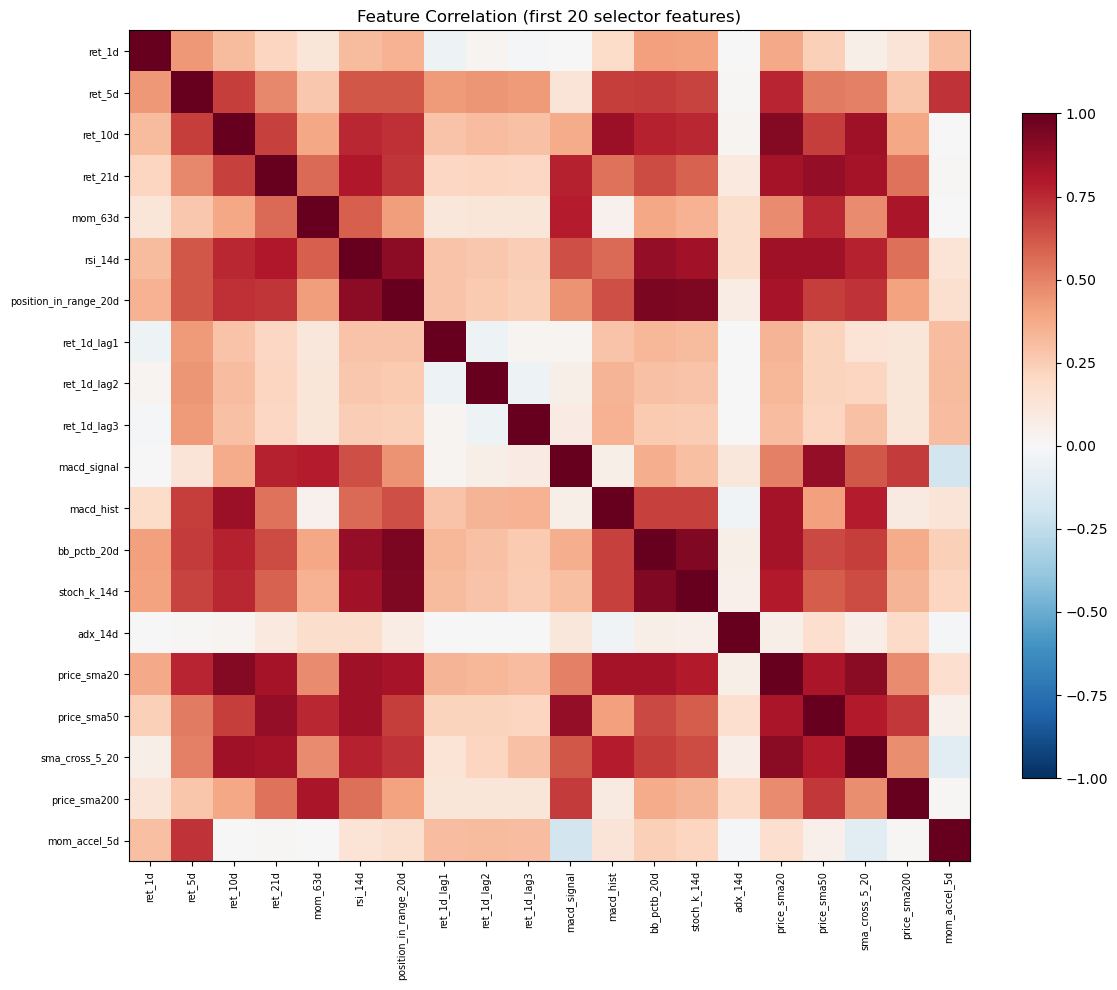

OK: No near-duplicate feature pairs


In [8]:
top_feats = full_cols[:20]
corr = df[top_feats].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(top_feats)))
ax.set_yticks(range(len(top_feats)))
ax.set_xticklabels(top_feats, rotation=90, fontsize=7)
ax.set_yticklabels(top_feats, fontsize=7)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Feature Correlation (first 20 selector features)')
plt.tight_layout()
plt.show()

# Check for near-duplicate features (|corr| > 0.99)
high_corr = []
for i in range(len(full_cols)):
    for j in range(i+1, len(full_cols)):
        c = df[[full_cols[i], full_cols[j]]].dropna().corr().iloc[0, 1]
        if abs(c) > 0.99:
            high_corr.append((full_cols[i], full_cols[j], c))
if high_corr:
    print(f"WARNING: {len(high_corr)} near-duplicate pairs (|corr|>0.99):")
    for a, b, c in high_corr[:5]:
        print(f"  {a} <-> {b}: {c:.4f}")
else:
    print("OK: No near-duplicate feature pairs")

## 7. Feature List vs Script Output

In [9]:
# Cross-check with script-exported feature list
feat_csv_path = cfg.dir_outputs / 'metrics' / 'feature_columns.csv'
if feat_csv_path.exists():
    feat_csv = pd.read_csv(feat_csv_path)
    script_feats = set(feat_csv[feat_csv['bucket'].isin(['base', 'macro_interaction'])]['feature'])
    nb_feats = set(full_cols)
    
    only_script = script_feats - nb_feats
    only_nb = nb_feats - script_feats
    
    if only_script:
        print(f"WARNING: In script but not notebook: {only_script}")
    if only_nb:
        print(f"WARNING: In notebook but not script: {only_nb}")
    if not only_script and not only_nb:
        print(f"OK: Feature list matches script output ({len(script_feats)} features)")
else:
    print("SKIP: feature_columns.csv not found — run scripts/run_features.py first")

OK: Feature list matches script output (58 features)


In [10]:
print("=" * 50)
print("02_features: ALL CHECKS PASSED")
print(f"  Shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"  Selector features: {len(full_cols)} ({len(base_cols)} base + {len(macro_cols)} macro)")
print(f"  NaN rate: {df[full_cols].isna().mean().mean():.2%}")
print("=" * 50)

02_features: ALL CHECKS PASSED
  Shape: 173,604 rows x 80 cols
  Selector features: 58 (48 base + 10 macro)
  NaN rate: 0.84%
